# Four-Spacecraft Methods
author: Louis Richard\
Gradients, curlometer, timing and pressure-strain from four-point
measurements, applied to synthetic fields measured by a regular
tetrahedron. As the fields are known analytically, the estimates can be
checked, and their limits shown. See [Paschmann and Daly (1998)](https://www.issibern.ch/forads/sr-001.pdf)
for the methods.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy import constants

from pyrfu import pyrf
from pyrfu.plot import plot_line, use_pyrfu_style

use_pyrfu_style(usetex=False)

Load IGRF coefficients ...


## Spacecraft configuration
### Time lines
60 s of 16 Hz magnetic field, and spacecraft positions every 10 s (the
positions are resampled to the field time line by the four-spacecraft
routines).

In [ ]:
tint = ["2019-09-14T07:54:00.000", "2019-09-14T07:55:00.000"]
t_start = pyrf.iso86012datetime64(np.array(tint))[0]


def time_line(f_s, duration=60.0):
    n_t = int(duration * f_s) + 1
    return t_start + (np.arange(n_t) / f_s * 1e9).astype("timedelta64[ns]")


time_b, time_r = time_line(16.0), time_line(0.1)
t_sec = (time_b - t_start).astype(np.int64) * 1e-9

### Regular tetrahedron
Regular tetrahedron with 20 km separation, centered at
$\mathbf{r}_0 = (10, 0, 0)~R_E$.

In [ ]:
d_sc = 20.0  # spacecraft separation [km]
r_0 = np.array([10.0, 0.0, 0.0]) * 6371.2  # barycenter [km]

vertices = np.array([[1, 1, 1], [1, -1, -1], [-1, 1, -1], [-1, -1, 1]]) / np.sqrt(8)
dr_mms = d_sc * vertices

r_mms = [
    pyrf.ts_vec_xyz(time_r, np.tile(r_0 + dr, (len(time_r), 1)), {"UNITS": "km"})
    for dr in dr_mms
]

print(np.linalg.norm(dr_mms[:, None, :] - dr_mms[None, :, :], axis=-1))

[[ 0. 20. 20. 20.]
 [20.  0. 20. 20.]
 [20. 20.  0. 20.]
 [20. 20. 20.  0.]]


### Reciprocal vectors
The reciprocal vectors $\mathbf{k}_\alpha$ are the building blocks of the
linear estimates: the gradient of a quantity $f$ is
$\nabla f \approx \sum_\alpha \mathbf{k}_\alpha f_\alpha$. They sum to zero
and satisfy
$\sum_\alpha \mathbf{k}_\alpha \otimes \mathbf{r}_\alpha = \mathbf{I}$.

In [ ]:
k_mms = pyrf.c_4_k(r_mms)

print(np.sum([k_.data[0] for k_ in k_mms], axis=0))
print(
    np.sum([np.outer(k_.data[0], r_.data[0]) for k_, r_ in zip(k_mms, r_mms)], axis=0)
)

[0. 0. 0.]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


## Linear magnetic field
For a linear field
$\mathbf{B}(\mathbf{r}) = \mathbf{B}_0 + \mathbf{G}\cdot(\mathbf{r} - \mathbf{r}_0)$
the linear estimates are exact: the gradient is $\mathbf{G}$ and the field at
the barycenter is $\mathbf{B}_0$. $\mathbf{G}$ is traceless
($\nabla\cdot\mathbf{B} = 0$), and the curl of the field is
$\nabla\times\mathbf{B} = (G_{zy} - G_{yz}, G_{xz} - G_{zx}, G_{yx} - G_{xy})$.

In [ ]:
b_0 = np.array([5.0, -10.0, 20.0])  # [nT]
g_mat = np.array([[0.2, 0.5, -0.1], [-0.3, 0.1, 0.4], [0.6, 0.0, -0.3]])  # [nT/km]

b_lin = [
    pyrf.ts_vec_xyz(
        time_b, np.tile(b_0 + g_mat @ dr, (len(time_b), 1)), {"UNITS": "nT"}
    )
    for dr in dr_mms
]

grad_b = pyrf.c_4_grad(r_mms, b_lin, "grad")
print(grad_b.dims)
print(grad_b.data[0])

('time', 'vcomp', 'hcomp')
[[ 2.00000000e-01  5.00000000e-01 -1.00000000e-01]
 [-3.00000000e-01  1.00000000e-01  4.00000000e-01]
 [ 6.00000000e-01 -5.55111512e-17 -3.00000000e-01]]


`c_4_grad` returns $\partial_i B_j$ with the field component $j$ along
`vcomp` and the derivative $i$ along `hcomp`, i.e., the same layout as
$\mathbf{G}$ here. The divergence, curl and the field at the barycenter are
recovered exactly.

In [ ]:
curl_g = np.array(
    [g_mat[2, 1] - g_mat[1, 2], g_mat[0, 2] - g_mat[2, 0], g_mat[1, 0] - g_mat[0, 1]],
)

print("div B :", pyrf.c_4_grad(r_mms, b_lin, "div").data[0])
print("curl B:", pyrf.c_4_grad(r_mms, b_lin, "curl").data[0], "expected", curl_g)
print("<B>   :", pyrf.avg_4sc(b_lin).data[0], "expected", b_0)

div B : 6.905587213168474e-14
curl B: [-0.4 -0.7 -0.8] expected [-0.4 -0.7 -0.8]
<B>   : [  5. -10.  20.] expected [  5. -10.  20.]


`c_4_j` gives the current density $\mathbf{J} = \nabla\times\mathbf{B}/\mu_0$
in A m$^{-2}$, with $\nabla\cdot\mathbf{B}/\mu_0$ (in the same units, as an
error estimate), the field at the barycenter, the $\mathbf{J}\times\mathbf{B}$
force and its decomposition into the curvature force and the magnetic
pressure gradient (in N m$^{-3}$).

In [ ]:
j_lin, div_b_lin, _, jxb_lin, _, _ = pyrf.c_4_j(r_mms, b_lin)

print("J      :", j_lin.data[0] * 1e9, "nA/m^2")
print("J      :", curl_g * 1e-12 / constants.mu_0 * 1e9, "nA/m^2 (expected)")
print("JxB    :", jxb_lin.data[0], "N/m^3")
print(
    "JxB    :",
    np.cross(curl_g * 1e-12 / constants.mu_0, b_0 * 1e-9),
    "N/m^3 (expected)",
)

J      : [-318.30988623 -557.0423009  -636.61977245] nA/m^2
J      : [-318.30988623 -557.0423009  -636.61977245] nA/m^2 (expected)
JxB    : [-1.75070437e-14  3.18309886e-15  5.96831037e-15] N/m^3
JxB    : [-1.75070437e-14  3.18309886e-15  5.96831037e-15] N/m^3 (expected)


## Current sheet
A Harris current sheet
$\mathbf{B} = B_0 \tanh(s / L)\,\hat{\mathbf{l}} + B_g\,\hat{\mathbf{m}}$
with $s = \hat{\mathbf{n}}\cdot(\mathbf{r} - \mathbf{r}_0) - V_n (t - t_c)$
moves along its normal $\hat{\mathbf{n}}$ at $V_n$ and crosses the
barycenter at $t_c$. The current density is along $\hat{\mathbf{m}}$,
$J_m = B_0 / (\mu_0 L)\,\mathrm{sech}^2(s / L)$.

In [ ]:
n_hat = pyrf.normalize(pyrf.ts_vec_xyz(time_b[:1], np.array([[0.3, 0.2, 1.0]]))).data[0]
l_hat = np.cross([0.0, 1.0, 0.0], n_hat)
l_hat /= np.linalg.norm(l_hat)
m_hat = np.cross(n_hat, l_hat)

b_lobe, b_guide = 20.0, 5.0  # [nT]
v_n, t_c = 20.0, 30.0  # [km/s], [s]


def harris_sheet(dr, thickness):
    s_n = np.dot(dr, n_hat) - v_n * (t_sec - t_c)
    b_data = b_lobe * np.tanh(s_n / thickness)[:, None] * l_hat
    b_data += b_guide * m_hat
    return pyrf.ts_vec_xyz(time_b, b_data, {"UNITS": "nT"})


def harris_current(thickness):
    s_n = -v_n * (t_sec - t_c)
    j_m = b_lobe * 1e-12 / (constants.mu_0 * thickness) / np.cosh(s_n / thickness) ** 2
    return pyrf.ts_scalar(time_b, j_m, {"UNITS": "A/m^2"})


l_thick = 200.0  # sheet half-thickness [km], 10 times the separation
b_mms = [harris_sheet(dr, l_thick) for dr in dr_mms]
j_xyz, div_b, b_xyz, _, _, _ = pyrf.c_4_j(r_mms, b_mms)

### Curlometer accuracy
The curlometer assumes that the field varies linearly across the
tetrahedron. The ratio $|\nabla\cdot\mathbf{B}| / |\nabla\times\mathbf{B}|$
is a common quality indicator, with values below 0.2-0.3 usually considered
acceptable. A sheet 10 times thicker than the separation is well resolved.
For a sheet 4 times thinner than the separation, the ratio stays around 0.2
although the peak current is underestimated by about 40%: a small
$\nabla\cdot\mathbf{B}$ is necessary, but not sufficient, for an accurate
current. The ratio is only computed where the current is larger than 20% of
its peak, as it is undefined outside the sheet.

In [ ]:
l_thin = 5.0
b_mms_thin = [harris_sheet(dr, l_thin) for dr in dr_mms]
j_xyz_thin, div_b_thin, _, _, _, _ = pyrf.c_4_j(r_mms, b_mms_thin)

for l_cs, j_cs, div_cs in zip(
    [l_thick, l_thin], [j_xyz, j_xyz_thin], [div_b, div_b_thin]
):
    j_m = pyrf.dot(j_cs, pyrf.ts_vec_xyz(time_b, np.tile(m_hat, (len(time_b), 1))))
    j_true = harris_current(l_cs)
    ratio = (np.abs(div_cs) / pyrf.norm(j_cs))[j_true > 0.2 * j_true.max()]
    print(
        f"L = {l_cs:5.1f} km: max(J_m) = {j_m.max().data * 1e9:6.1f} nA/m^2"
        f" (expected {j_true.max().data * 1e9:6.1f}),"
        f" median(|div B|/|curl B|) = {ratio.median().data:.2f}"
    )

L = 200.0 km: max(J_m) =   79.5 nA/m^2 (expected   79.6), median(|div B|/|curl B|) = 0.01
L =   5.0 km: max(J_m) = 1839.0 nA/m^2 (expected 3183.1), median(|div B|/|curl B|) = 0.16


## Timing
### Velocity of the discontinuity
The times at which each spacecraft observes the center of the sheet
($B_l = 0$) give the velocity of the sheet along its normal, assuming that
it is planar and moves at constant velocity.

In [ ]:
t_cross = []

for b_sc in b_mms:
    b_l = b_sc.data @ l_hat
    t_cross.append(np.interp(0.0, -b_l, t_sec))

t_cross = t_start + (np.array(t_cross) * 1e9).astype("timedelta64[ns]")
print(t_cross)

v_timing = pyrf.c_4_v(r_mms, t_cross)
print("V      :", v_timing, "km/s")
print("V n    :", v_n * n_hat, "km/s (expected)")

['2019-09-14T07:54:30.498892565' '2019-09-14T07:54:29.700664530'
 '2019-09-14T07:54:29.634145514' '2019-09-14T07:54:30.166297467']
V      : [ 5.6443314   3.7628876  18.81442451] km/s
V n    : [ 5.64432521  3.76288347 18.81441737] km/s (expected)


### Time delays from a velocity
Conversely, given a reference time and the velocity of the discontinuity,
`c_4_v` gives the expected time delays with respect to MMS1, e.g., to check
a velocity from another method.

In [ ]:
dt_timing = pyrf.c_4_v(r_mms, [t_cross[0], *v_timing])
print("dt     :", dt_timing, "s")
print("dt     :", (t_cross - t_cross[0]).astype(np.int64) * 1e-9, "s (observed)")

dt     : [ 0.         -0.79822779 -0.86474681 -0.33259511] s
dt     : [ 0.         -0.79822804 -0.86474705 -0.3325951 ] s (observed)


## Pressure-strain interaction
`pid_4sc` computes the deviatoric part of the strain tensor $D_{ij}$, the
deviatoric pressure tensor $\Pi_{ij}$, the compressive term $p\theta$ and
$\mathrm{Pi\text{-}D} = -\Pi_{ij}D_{ij}$ from the bulk velocity and the
pressure tensor measured by the four spacecraft. For a shear flow
$u_x = S z$ and a pressure tensor with $\Pi_{xz} = \Pi_{zx} = \pi$, the only
nonzero strain components are $D_{xz} = D_{zx} = S / 2$, so
$\mathrm{Pi\text{-}D} = -\pi S$ and $p\theta = 0$. With the velocity in km/s,
the positions in km and the pressure in nPa, $\mathrm{Pi\text{-}D}$ is in
nW m$^{-3}$.

In [ ]:
s_shear, pi_xz, p_iso = 0.5, 0.05, 0.5  # [1/s], [nPa], [nPa]

v_mms, p_mms = [], []

for dr in dr_mms:
    v_data = np.tile([s_shear * dr[2], 0.0, 0.0], (len(time_b), 1))
    v_mms.append(pyrf.ts_vec_xyz(time_b, v_data, {"UNITS": "km/s"}))

    p_data = p_iso * np.eye(3)
    p_data[0, 2] = p_data[2, 0] = pi_xz
    p_mms.append(pyrf.ts_tensor_xyz(time_b, np.tile(p_data, (len(time_b), 1, 1))))

d_xyz, pi_xyz, p_theta, pid = pyrf.pid_4sc(r_mms, v_mms, p_mms)

print("D      :", d_xyz.data[0].round(3).tolist())
print("p theta:", p_theta.data[0], "nW/m^3")
print("Pi-D   :", pid.data[0], "nW/m^3, expected", -pi_xz * s_shear)

D      : [[0.0, 0.0, 0.25], [0.0, 0.0, 0.0], [0.25, 0.0, 0.0]]
p theta: 0.0 nW/m^3
Pi-D   : -0.024999999999999998 nW/m^3, expected -0.025


## Plot
Thick (left) and thin (right) current sheets. The dotted lines are the
crossing times of the thick sheet used for timing.

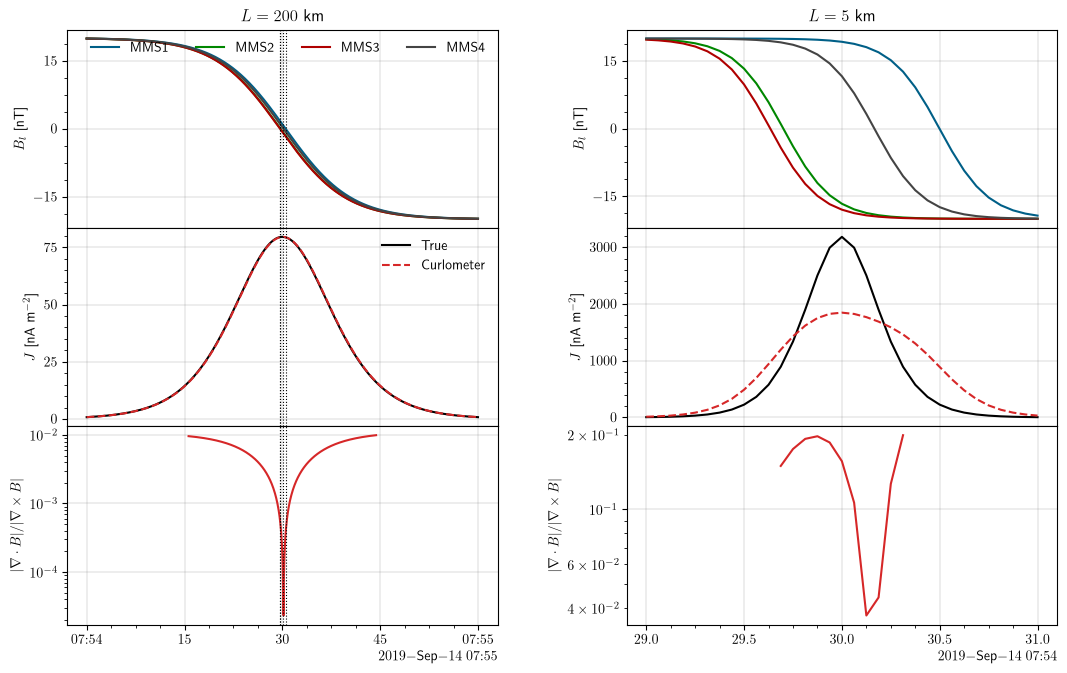

In [ ]:
f, axs = plt.subplots(3, 2, sharex="col", figsize=(11, 7))
f.subplots_adjust(hspace=0, wspace=0.3, left=0.08, right=0.98, top=0.93, bottom=0.08)

# Zoom on the thin sheet
tint_thin = t_start + (np.array([t_c - 1.0, t_c + 1.0]) * 1e9).astype("timedelta64[ns]")

for i, (l_cs, b_cs, j_cs, div_cs, tint_cs) in enumerate(
    zip(
        [l_thick, l_thin],
        [b_mms, b_mms_thin],
        [j_xyz, j_xyz_thin],
        [div_b, div_b_thin],
        [time_b[[0, -1]], tint_thin],
    ),
):
    axs[0, i].set_title(f"$L = {l_cs:.0f}$ km")

    for b_sc in b_cs:
        plot_line(
            axs[0, i],
            pyrf.time_clip(pyrf.ts_scalar(time_b, b_sc.data @ l_hat), tint_cs),
        )

    j_true = pyrf.time_clip(harris_current(l_cs), tint_cs)
    j_curl = pyrf.time_clip(pyrf.norm(j_cs), tint_cs)
    plot_line(axs[1, i], j_true * 1e9, color="k")
    plot_line(axs[1, i], j_curl * 1e9, color="tab:red", linestyle="--")

    ratio = pyrf.time_clip(np.abs(div_cs) / pyrf.norm(j_cs), tint_cs)
    plot_line(axs[2, i], ratio.where(j_true > 0.2 * j_true.max()), color="tab:red")

    axs[0, i].set_ylabel("$B_l$ [nT]")
    axs[1, i].set_ylabel("$J$ [nA m$^{-2}$]")
    axs[2, i].set_ylabel(r"$|\nabla\cdot B| / |\nabla\times B|$")
    axs[2, i].set_yscale("log")

axs[0, 0].legend(
    ["MMS1", "MMS2", "MMS3", "MMS4"], ncol=4, loc="upper right", frameon=False
)
axs[1, 0].legend(["True", "Curlometer"], loc="upper right", frameon=False)

for ax in axs[:, 0]:
    for t_ in t_cross:
        ax.axvline(t_, color="k", linestyle=":", linewidth=0.8)